In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")



/tmp/ipython-input-270462183.py:6: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("/content/historical_data.csv")


In [3]:
trades.head(), sentiment.head()

(                                      Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
 3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
 4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   
 
    Closed PnL                                   Transaction Hash     Order ID  \
 0      

In [4]:
trades.isnull().sum(), sentiment.isnull().sum()


(Account             0
 Coin                0
 Execution Price     0
 Size Tokens         0
 Size USD            0
 Side                0
 Timestamp IST       0
 Start Position      0
 Direction           0
 Closed PnL          0
 Transaction Hash    0
 Order ID            0
 Crossed             0
 Fee                 0
 Trade ID            0
 Timestamp           0
 dtype: int64,
 timestamp         0
 value             0
 classification    0
 date              0
 dtype: int64)

In [5]:
# Adjust column names if different
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], errors="coerce")
sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce")

In [6]:
# Keep only valid rows
trades = trades.dropna(subset=["Timestamp IST"])
sentiment = sentiment.dropna(subset=["date"])

In [7]:
# Extract pure date for join, ensuring datetime64[ns] type
trades.loc[:, "date"] = trades["Timestamp IST"].dt.normalize()
sentiment.loc[:, "date"] = pd.to_datetime(sentiment["date"], errors="coerce").dt.normalize()

In [8]:
# Check unique sentiment labels
sentiment["classification"].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [9]:
sentiment_clean = sentiment[["date", "classification"]].drop_duplicates()

# Explicitly ensure 'date' columns are datetime64[ns] and normalized before merge
trades['date'] = pd.to_datetime(trades['date'], errors='coerce').dt.normalize()
sentiment_clean['date'] = pd.to_datetime(sentiment_clean['date'], errors='coerce').dt.normalize()

merged = trades.merge(
    sentiment_clean,
    on="date",
    how="left"
)

merged["classification"].value_counts(dropna=False).head()
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [12]:
merged.to_csv("merged_trades_sentiment.csv", index=False)

print("Saved merged CSV at: csv_files/merged_trades_sentiment.csv")

Saved merged CSV at: csv_files/merged_trades_sentiment.csv


In [13]:
# Ensure numeric columns
for col in ["Execution Price", "Size Tokens", "Closed PnL", "leverage"]:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors="coerce")

merged = merged.dropna(subset=["Execution Price", "Size Tokens", "Closed PnL"])

merged["notional"] = (merged["Execution Price"].abs() * merged["Size Tokens"].abs())
merged["notional"] = merged["notional"].replace(0, np.nan)

merged["pnl_per_notional"] = merged["Closed PnL"] / merged["notional"]

merged["win"] = (merged["Closed PnL"] > 0).astype(int)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,notional,pnl_per_notional,win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,7872.163303,0.0,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,127.680000,0.0,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,1150.630695,0.0,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,1142.038452,0.0,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,69.747462,0.0,0


In [14]:
perf_by_sentiment = (
    merged
    .groupby("classification")
    .agg(
        n_trades=("Closed PnL", "count"),
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        median_pnl=("Closed PnL", "median"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

perf_by_sentiment

,classification,n_trades,total_pnl,avg_pnl,median_pnl,win_rate
0,Extreme Fear,2326,4.399937e+03,1.891632,0.00000,0.292777
1,Extreme Greed,5621,1.156894e+06,205.816345,0.96048,0.553282
2,Fear,13869,1.779226e+06,128.287950,0.00000,0.381787
3,Greed,11292,6.096325e+05,53.988003,0.00000,0.435707
4,Neutral,2756,7.465674e+04,27.088803,0.00000,0.494920


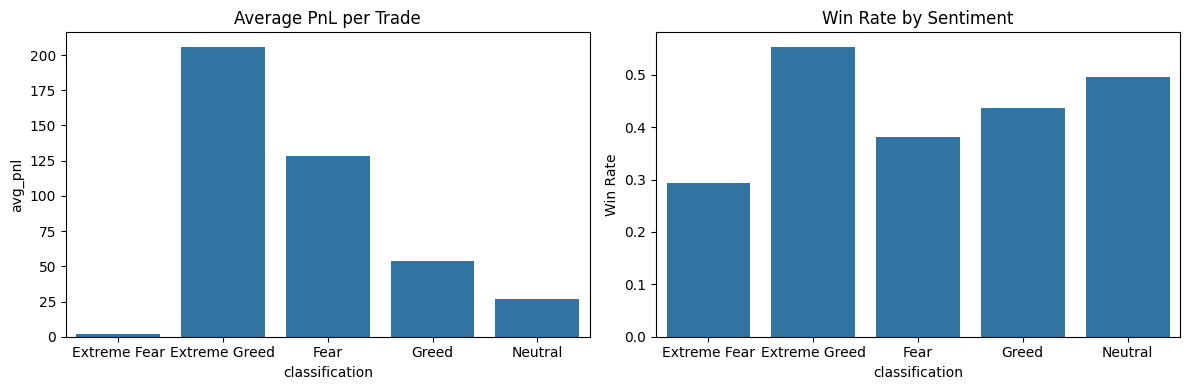

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=perf_by_sentiment,
    x="classification", y="avg_pnl", ax=axes[0]
)
axes[0].set_title("Average PnL per Trade")

sns.barplot(
    data=perf_by_sentiment,
    x="classification", y="win_rate", ax=axes[1]
)
axes[1].set_title("Win Rate by Sentiment")
axes[1].set_ylabel("Win Rate")

plt.tight_layout()
plt.show()

In [16]:
acc_sent = (
    merged
    .groupby(["Account", "classification"])
    .agg(
        n_trades=("Closed PnL", "count"),
        avg_pnl=("Closed PnL", "mean"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

acc_pivot = acc_sent.pivot(
    index="Account",
    columns="classification",
    values="avg_pnl"
)

# Compute difference: Greed minus Fear
if "Greed" in acc_pivot.columns and "Fear" in acc_pivot.columns:
    acc_pivot["greed_minus_fear"] = acc_pivot["Greed"] - acc_pivot["Fear"]

acc_pivot.head()

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral,greed_minus_fear
Account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,NaN,0.000000,502.539343,-151.066687,NaN,-653.606030
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.000000,NaN,11.443636,9.952624,39.340428,-1.491012
0x271b280974205ca63b716753467d5a371de622ab,NaN,NaN,NaN,52.204365,NaN,NaN
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2.598012,41.035811,19.091706,21.873886,4.469915,2.782180
0x2c229d22b100a7beb69122eed721cee9b24011dd,6.158762,125.115313,-47.385796,145.996529,10.906974,193.382325


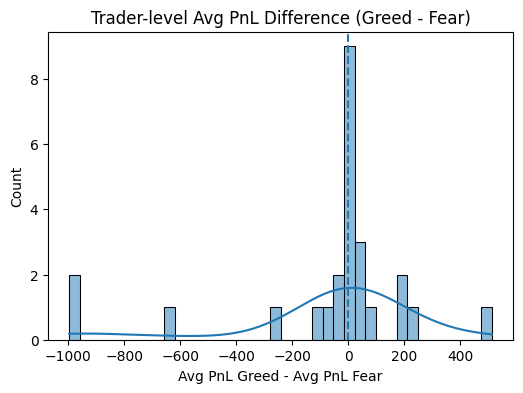

In [17]:
if "greed_minus_fear" in acc_pivot.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(acc_pivot["greed_minus_fear"].dropna(), bins=40, kde=True)
    plt.axvline(0, linestyle="--")
    plt.title("Trader-level Avg PnL Difference (Greed - Fear)")
    plt.xlabel("Avg PnL Greed - Avg PnL Fear")
    plt.show()


In [18]:
side_sentiment = (
    merged
    .groupby(["classification", "Side"])
    .agg(
        n_trades=("Closed PnL", "count"),
        avg_pnl=("Closed PnL", "mean"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

side_sentiment

,classification,Side,n_trades,avg_pnl,win_rate
0,Extreme Fear,BUY,1168,-3.248825,0.062500
1,Extreme Fear,SELL,1158,7.076480,0.525043
2,Extreme Greed,BUY,1661,9.047055,0.311258
3,Extreme Greed,SELL,3960,288.350131,0.654798
4,Fear,BUY,7307,210.426466,0.338443
5,Fear,SELL,6562,36.824047,0.430052
6,Greed,BUY,5407,15.661324,0.296837
7,Greed,SELL,5885,89.201657,0.563297
8,Neutral,BUY,1020,12.484274,0.326471
9,Neutral,SELL,1736,35.669805,0.593894


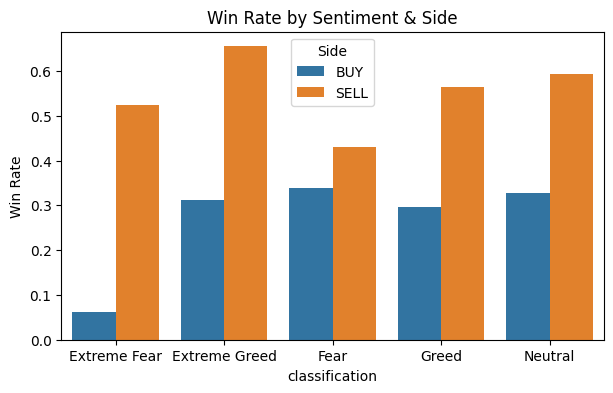

In [19]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=side_sentiment,
    x="classification", y="win_rate", hue="Side"
)
plt.title("Win Rate by Sentiment & Side")
plt.ylabel("Win Rate")
plt.show()


In [20]:
# Ensure date column is datetime (you already created it earlier)
merged["date"] = pd.to_datetime(merged["date"]).dt.date

# Daily volatility features based on Execution Price
daily_vol = (
    merged.groupby("date")["Execution Price"]
    .agg(["std", "max", "min", "mean"])
    .rename(columns={"std": "price_std"})
)

daily_vol["price_range"] = daily_vol["max"] - daily_vol["min"]

# Attach dominant sentiment for each date
daily_sentiment = (
    merged.groupby("date")["classification"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)  # most common sentiment that day
    .to_frame()
)

daily_vol_sent = daily_vol.join(daily_sentiment, on="date")
daily_vol_sent.head()

,price_std,max,min,mean,price_range,classification
date,,,,,,
2023-01-05,0.404145,1898.60000,1897.900000,1898.133333,0.700000,Fear
2023-05-12,17477.946554,41867.00000,2230.100000,11038.300000,39636.900000,Neutral
2024-01-01,17773.706148,42693.00000,14.940000,10373.330667,42678.060000,Greed
2024-01-02,0.087673,0.25435,0.024577,0.076126,0.229773,Greed
2024-01-03,2.904074,8.11690,0.004018,2.725657,8.112882,Greed


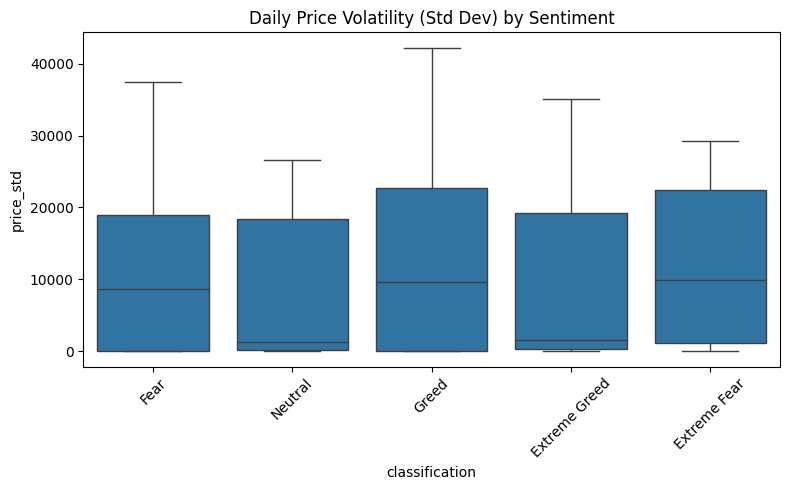

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=daily_vol_sent,
    x="classification",
    y="price_std"
)
plt.xticks(rotation=45)
plt.title("Daily Price Volatility (Std Dev) by Sentiment")
plt.tight_layout()
plt.show()


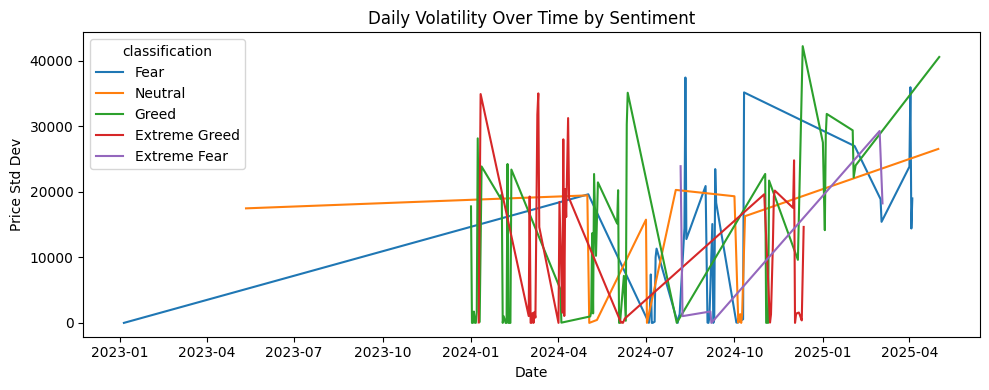

In [22]:
plt.figure(figsize=(10,4))
sns.lineplot(
    data=daily_vol_sent.reset_index(),
    x="date",
    y="price_std",
    hue="classification"
)
plt.title("Daily Volatility Over Time by Sentiment")
plt.xlabel("Date")
plt.ylabel("Price Std Dev")
plt.tight_layout()
plt.show()


In [23]:
symbol_sentiment = (
    merged
    .groupby(["Coin", "classification"])
    .agg(
        n_trades=("Closed PnL", "count"),
        avg_pnl=("Closed PnL", "mean"),
        win_rate=("win", "mean")
    )
    .reset_index()
)

symbol_sentiment.head()


,Coin,classification,n_trades,avg_pnl,win_rate
0,@1,Fear,2,8.664499,0.5
1,@1,Greed,1,-47.982752,0.0
2,@10,Fear,1,0.000000,0.0
3,@10,Greed,2,-0.031742,0.0
4,@103,Greed,2,4.985462,0.5


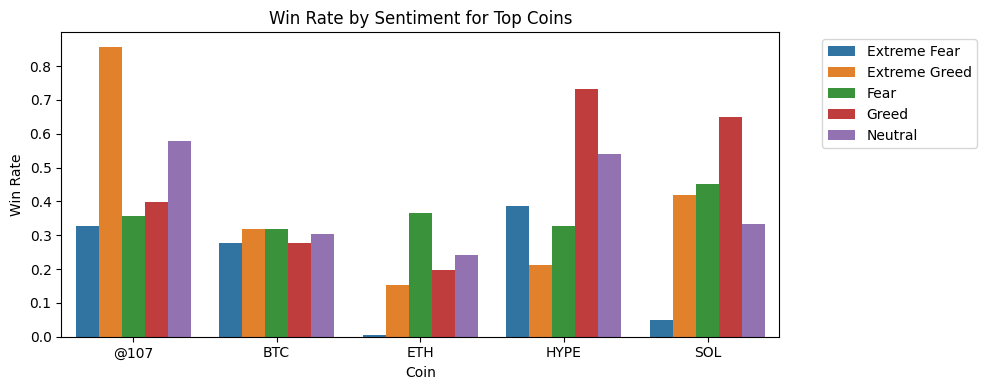

In [40]:
# Focus on top N most traded coins
top_coins = (
    merged["Coin"].value_counts()
    .head(5)
    .index.tolist()
)

sym_plot = symbol_sentiment[symbol_sentiment["Coin"].isin(top_coins)]

plt.figure(figsize=(10,4))
sns.barplot(
    data=sym_plot,
    x="Coin",
    y="win_rate",
    hue="classification"
)
plt.title("Win Rate by Sentiment for Top Coins")
plt.ylabel("Win Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [25]:
if "leverage" in merged.columns:
    # Drop weird / zero values if any
    merged["leverage"] = pd.to_numeric(merged["leverage"], errors="coerce")

    # Buckets for leverage and trade size
    merged["lev_bucket"] = pd.cut(
        merged["leverage"],
        bins=[0, 3, 5, 10, 20, 50, np.inf],
        labels=["0–3x", "3–5x", "5–10x", "10–20x", "20–50x", ">50x"],
        include_lowest=True
    )

    merged["size_bucket"] = pd.qcut(
        merged["Size Tokens"],
        q=4,
        labels=["Small", "Medium", "Large", "Very Large"]
    )

    heatmap_df = (
        merged
        .groupby(["lev_bucket", "size_bucket"])
        .agg(avg_pnl=("Closed PnL", "mean"))
        .reset_index()
        .pivot(index="lev_bucket", columns="size_bucket", values="avg_pnl")
    )

    plt.figure(figsize=(6,4))
    sns.heatmap(heatmap_df, annot=True, fmt=".1f")
    plt.title("Avg PnL by Leverage & Size Bucket")
    plt.xlabel("Size Bucket")
    plt.ylabel("Leverage Bucket")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'leverage' not in dataset – skipping leverage-size interaction heatmap.")

Column 'leverage' not in dataset – skipping leverage-size interaction heatmap.


In [26]:
# Daily performance aggregation
daily_perf = (
    merged
    .groupby(["date", "classification"])
    .agg(
        win_rate=("win", "mean"),
        avg_pnl=("Closed PnL", "mean"),
        volume_usd=("Size USD", "sum"),
        n_trades=("Closed PnL", "count")
    )
    .reset_index()
)

daily_perf.head()


,date,classification,win_rate,avg_pnl,volume_usd,n_trades
0,2023-01-05,Fear,0.000000,0.000000,477.00,3
1,2023-05-12,Neutral,0.000000,0.000000,50005.83,9
2,2024-01-01,Greed,0.055556,-7.196192,264239.53,18
3,2024-01-02,Greed,0.000000,0.000000,2008.18,6
4,2024-01-03,Greed,0.934307,60.176945,472974.70,137


In [27]:
# Daily performance aggregation
daily_perf = (
    merged
    .groupby(["date", "classification"])
    .agg(
        win_rate=("win", "mean"),
        avg_pnl=("Closed PnL", "mean"),
        volume_usd=("Size USD", "sum"),
        n_trades=("Closed PnL", "count")
    )
    .reset_index()
)

daily_perf.head()

,date,classification,win_rate,avg_pnl,volume_usd,n_trades
0,2023-01-05,Fear,0.000000,0.000000,477.00,3
1,2023-05-12,Neutral,0.000000,0.000000,50005.83,9
2,2024-01-01,Greed,0.055556,-7.196192,264239.53,18
3,2024-01-02,Greed,0.000000,0.000000,2008.18,6
4,2024-01-03,Greed,0.934307,60.176945,472974.70,137


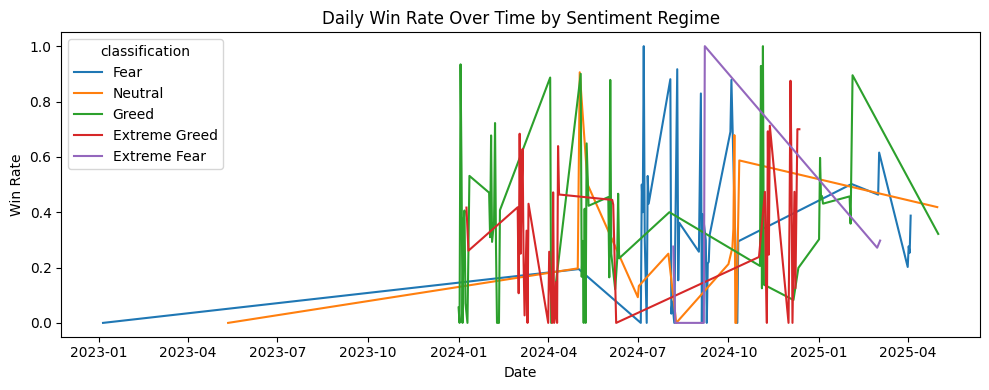

In [28]:
# Sort by date
daily_perf = daily_perf.sort_values("date")

# Simple line plot
plt.figure(figsize=(10,4))
sns.lineplot(
    data=daily_perf,
    x="date",
    y="win_rate",
    hue="classification"
)
plt.title("Daily Win Rate Over Time by Sentiment Regime")
plt.xlabel("Date")
plt.ylabel("Win Rate")
plt.tight_layout()
plt.show()


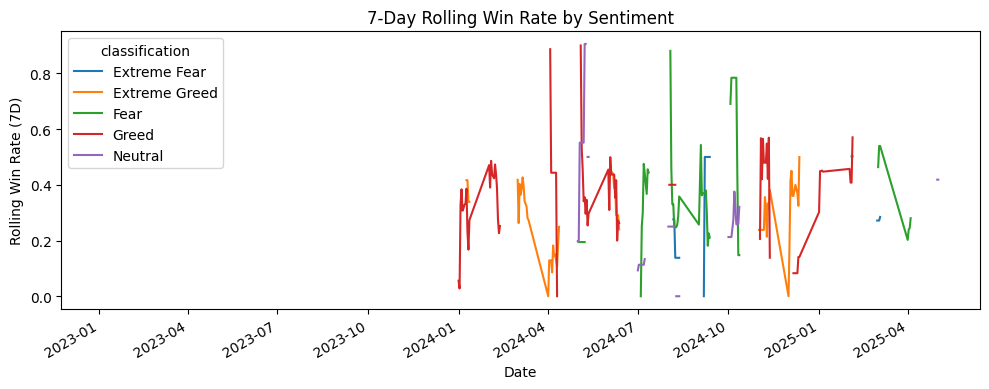

In [29]:
daily_perf["date"] = pd.to_datetime(daily_perf["date"])

daily_perf = daily_perf.sort_values("date")

# Pivot to one column per sentiment and compute rolling means
pivot_wr = daily_perf.pivot(
    index="date", columns="classification", values="win_rate"
).rolling("7D").mean()

pivot_wr.plot(figsize=(10,4))
plt.title("7-Day Rolling Win Rate by Sentiment")
plt.xlabel("Date")
plt.ylabel("Rolling Win Rate (7D)")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Aggregate behaviour per account
acc_stats = (
    merged
    .groupby("Account")
    .agg(
        avg_leverage=("leverage", "mean") if "leverage" in merged.columns else ("Closed PnL", lambda x: 0),
        avg_size_usd=("Size USD", "mean"),
        win_rate=("win", "mean"),
        pnl_mean=("Closed PnL", "mean"),
        pnl_std=("Closed PnL", "std"),
        n_trades=("Closed PnL", "count")
    )
    .fillna(0)
)

# Features for clustering
features = ["avg_size_usd", "win_rate", "pnl_mean", "pnl_std", "n_trades"]
if "leverage" in merged.columns:
    features.insert(0, "avg_leverage")

X = acc_stats[features]

# Scale and cluster
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
acc_stats["cluster"] = kmeans.fit_predict(X_scaled)

acc_stats.head()


,avg_leverage,avg_size_usd,win_rate,pnl_mean,pnl_std,n_trades,cluster
Account,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,0,16559.604299,0.435472,501.263878,4917.710509,2712,1
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0,2016.924491,0.468786,3.117217,144.724233,1730,0
0x271b280974205ca63b716753467d5a371de622ab,0,10937.581974,0.431579,26.473461,110.709563,1140,0
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0,448.915002,0.461217,9.598132,169.591101,4306,0
0x2c229d22b100a7beb69122eed721cee9b24011dd,0,2599.986060,0.531250,85.182721,380.350854,896,0


In [31]:
cluster_profile = acc_stats.groupby("cluster").mean()
cluster_profile


,avg_leverage,avg_size_usd,win_rate,pnl_mean,pnl_std,n_trades
cluster,,,,,,
0,0.0,6506.290269,0.381427,44.750409,444.566786,1782.846154
1,0.0,9214.968112,0.387782,380.113041,3318.729164,1307.000000
2,0.0,3180.407732,0.454138,107.228411,937.381002,9650.000000


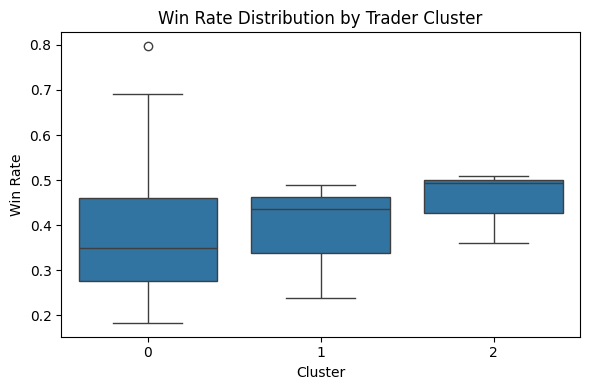

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=acc_stats.reset_index(),
    x="cluster",
    y="win_rate"
)
plt.title("Win Rate Distribution by Trader Cluster")
plt.xlabel("Cluster")
plt.ylabel("Win Rate")
plt.tight_layout()
plt.show()

In [33]:
position_fee_stats = (
    merged
    .groupby("classification")
    .agg(
        avg_fee=("Fee", "mean"),
        median_fee=("Fee", "median"),
        crossed_rate=("Crossed", "mean"),
        avg_start_position=("Start Position", "mean")
    )
    .reset_index()
)

position_fee_stats


,classification,avg_fee,median_fee,crossed_rate,avg_start_position
0,Extreme Fear,0.686479,0.102816,0.594153,21902.797505
1,Extreme Greed,0.835794,0.034977,0.543320,24593.241160
2,Fear,1.131521,0.105617,0.584036,8146.358518
3,Greed,1.092947,0.101071,0.693234,37276.787811
4,Neutral,0.922389,0.017402,0.576923,89199.587406


In [34]:
position_fee_stats = (
    merged
    .groupby("classification")
    .agg(
        avg_fee=("Fee", "mean"),
        median_fee=("Fee", "median"),
        crossed_rate=("Crossed", "mean"),
        avg_start_position=("Start Position", "mean")
    )
    .reset_index()
)

position_fee_stats


,classification,avg_fee,median_fee,crossed_rate,avg_start_position
0,Extreme Fear,0.686479,0.102816,0.594153,21902.797505
1,Extreme Greed,0.835794,0.034977,0.543320,24593.241160
2,Fear,1.131521,0.105617,0.584036,8146.358518
3,Greed,1.092947,0.101071,0.693234,37276.787811
4,Neutral,0.922389,0.017402,0.576923,89199.587406


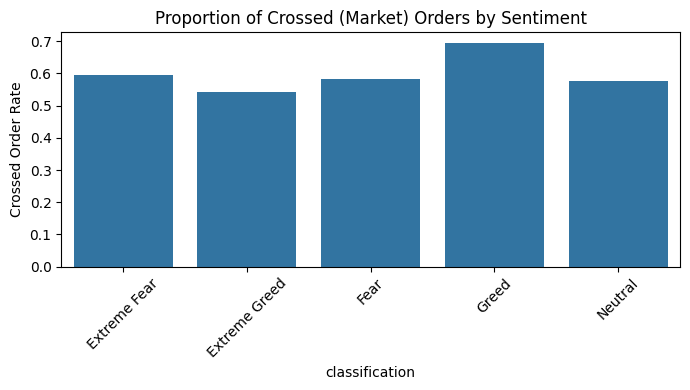

In [35]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=position_fee_stats,
    x="classification",
    y="crossed_rate"
)
plt.xticks(rotation=45)
plt.title("Proportion of Crossed (Market) Orders by Sentiment")
plt.ylabel("Crossed Order Rate")
plt.tight_layout()
plt.show()


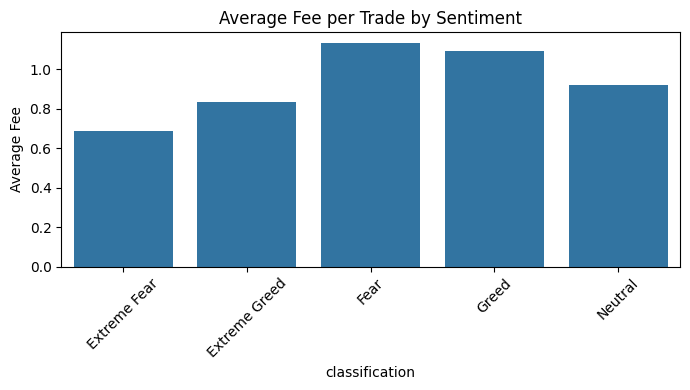

In [36]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=position_fee_stats,
    x="classification",
    y="avg_fee"
)
plt.xticks(rotation=45)
plt.title("Average Fee per Trade by Sentiment")
plt.ylabel("Average Fee")
plt.tight_layout()
plt.show()


In [37]:
extreme_df = merged[merged["classification"].isin(["Extreme Fear", "Extreme Greed"])]

extreme_stats = (
    extreme_df
    .groupby(["classification", "Side"])
    .agg(
        n_trades=("Closed PnL", "count"),
        avg_pnl=("Closed PnL", "mean"),
        win_rate=("win", "mean"),
        avg_fee=("Fee", "mean")
    )
    .reset_index()
)

extreme_stats

,classification,Side,n_trades,avg_pnl,win_rate,avg_fee
0,Extreme Fear,BUY,1168,-3.248825,0.062500,0.777102
1,Extreme Fear,SELL,1158,7.076480,0.525043,0.595074
2,Extreme Greed,BUY,1661,9.047055,0.311258,1.350293
3,Extreme Greed,SELL,3960,288.350131,0.654798,0.619990


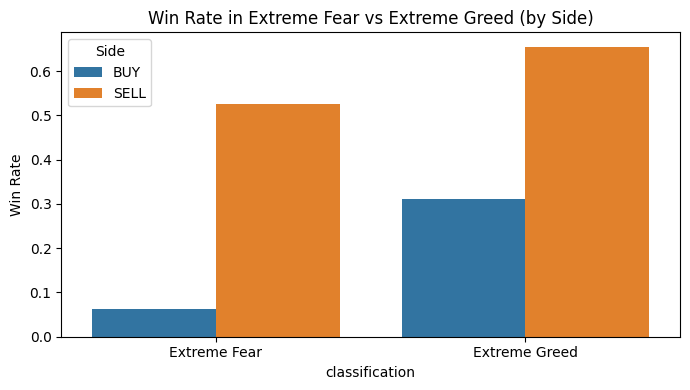

In [38]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=extreme_stats,
    x="classification",
    y="win_rate",
    hue="Side"
)
plt.title("Win Rate in Extreme Fear vs Extreme Greed (by Side)")
plt.ylabel("Win Rate")
plt.tight_layout()
plt.show()